## Access Satellite Austemp Dhd 8Day (Zarr)
This Jupyter notebook demonstrates how to access and plot satellite_austemp_dhd_8day data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/e1f2476a-b801-4a1f-9fbe-727b4f76f726).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/satellite_austemp_dhd_8day.ipynb).


In [1]:
dataset_name = "satellite_austemp_dhd_8day"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 201 packages in 66ms
Checked 201 packages in 1ms


✅ Local version 0.3.25 is up to date (remote: 0.3.25)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4677: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 366 ms, sys: 22.5 ms, total: 388 ms
Wall time: 898 ms


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	time = 141 ;
	lat = 1890 ;
	lon = 2685 ;

variables:
	float64 dhd(time, lat, lon) ;
		dhd:_ChunkSizes = [1, 500, 500] ;
		dhd:comment = Cumulative measure of heat stress above a defined temperature threshold, used for monitoring coral bleaching risk. ;
		dhd:long_name = degree heating days ;
		dhd:units = degrees_Celsius-days ;
		dhd:valid_max = 500.0 ;
		dhd:valid_min = 0.0 ;
	float64 dhd_count(time, lat, lon) ;
		dhd_count:_ChunkSizes = [1, 500, 500] ;
		dhd_count:comment = Number of days when the temperature exceeds a specific threshold, contributing to cumulative heat stress. ;
		dhd_count:long_name = degree heating days count ;
		dhd_count:units = 1 ;
		dhd_count:valid_max = 500.0 ;
		dhd_count:valid_min = 0.0 ;
	float64 dhd_count_mosaic(time, lat, lon) ;
		dhd_count_mosaic:_ChunkSizes = [1, 500, 500] ;
		dhd_count_mosaic:comment = A composite image combining multiple observations of degree heating days count over a specific period, typically 14 days.

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2012-01-01 15:20:00'), Timestamp('2012-12-20 15:20:00'))

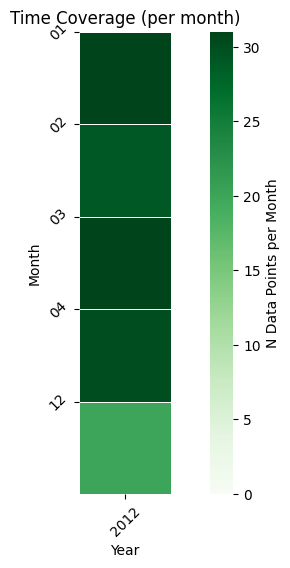

In [7]:
aodn_dataset.plot_time_coverage()

## Timeseries at a point

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:2220: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled = df[self.var_name].resample(resample)


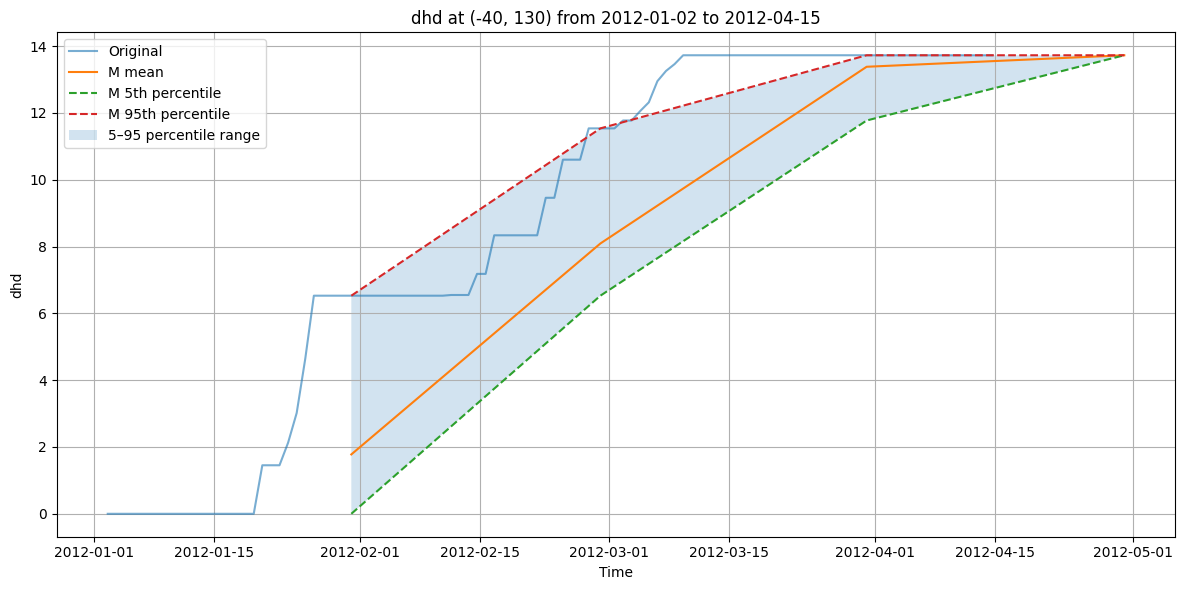

CPU times: user 737 ms, sys: 389 ms, total: 1.13 s
Wall time: 3.67 s


In [8]:
%%time
time_series_df = aodn_dataset.get_timeseries_data(var_name='dhd', 
                                                  lat=-40, 
                                                  lon=130, 
                                                  date_start='2012-01-02', 
                                                  date_end='2012-04-15', 
                                                  #lon_name_override="longitude", 
                                                  #lat_name_override="latitude"
                                                 ).plot_timeseries()

## Plot a gridded variable

2026-06-03 18:09:27,465 - aodn.GetAodn - INFO - Plotting 'degree heating days' for 12 time steps.
/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:3783: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


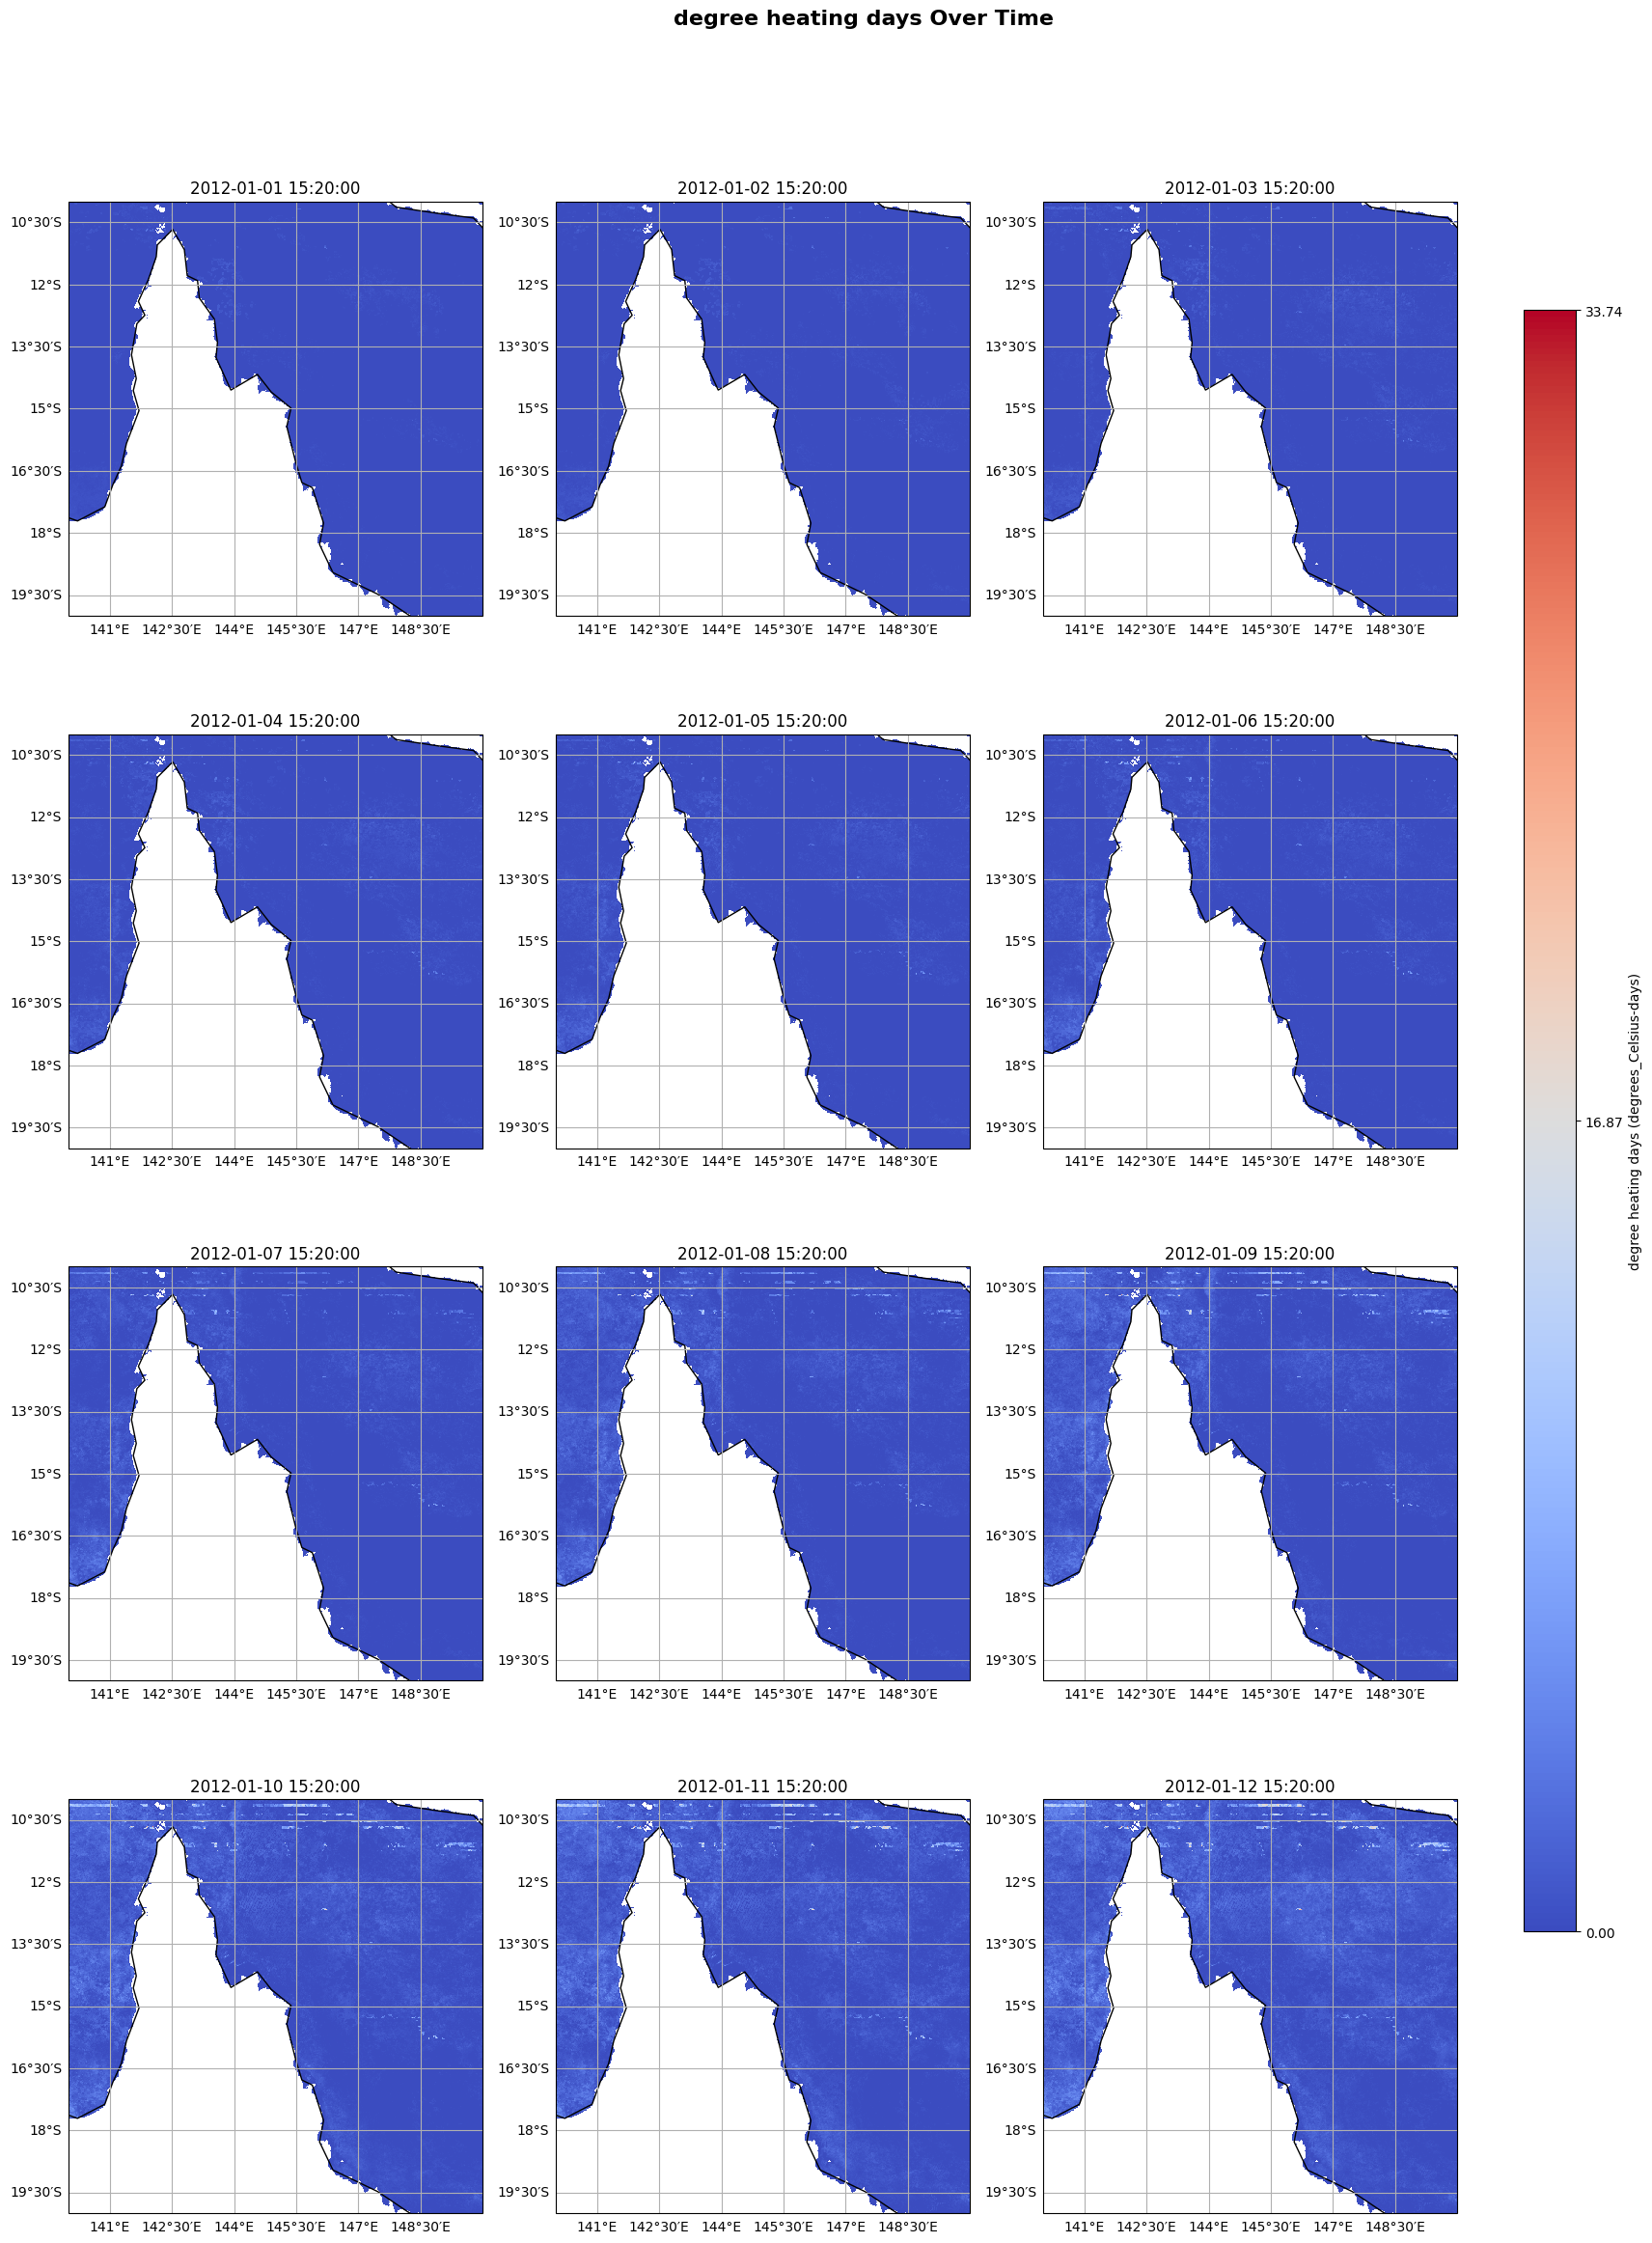

CPU times: user 11 s, sys: 4.4 s, total: 15.4 s
Wall time: 46.6 s


In [9]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='dhd', 
                                                    date_start='2012-01-02',                                                
                                                    #lon_name_override="longitude", 
                                                    #lat_name_override="latitude", 
                                                    lon_slice=(140, 150), 
                                                    lat_slice=(-20, -10), 
                                                    n_days=12, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False)